# Image Classification of Selected Threatened/Endangered Local Mammal Species in Singapore using Neural Networks

### how the hierarchy works:

#### species -- family -- order -- class

43364 CR sunda pangolin -- manidae -- pholidota (keratin scales) -- mammal



46134 CR red-cheeked flying squirrel -- sciuridae -- rodentia (rodents) -- mammal

46127 EN javanese/horsfield's flying squirrel -- sciuridae -- rodentia (rodents) -- mammal

45982 CR red giant flying squirrel -- sciuridae -- rodentia (rodents) -- mammal

46264 CR shrew-faced ground squirrel -- sciuridae -- rodentia (rodents) -- mammal



45343 CR rajah/brown spiny rat -- muridae -- rodentia (rodents) -- mammal



44172 CR east asian/malayan porcupine -- hystricidae -- rodentia (rodents) -- mammal



922738 CR mainland leopard cat -- felidae -- carnivora -- mammal



41602 CR small-toothed palm civet -- viverridae -- carnivora -- mammal

41625 CR masked palm civet -- viverridae -- carnivora -- mammal

41615 CR malay civet -- viverridae -- carnivora -- mammal

41613 CR large indian civet -- viverridae -- carnivora -- mammal



1638835 CR asian small-clawed otter -- mustelidae -- carnivora -- mammal

1638842 EN smooth-coated otter -- mustelidae -- carnivora -- mammal

https://www.nparks.gov.sg/nature/species-list/terrestrial-mammals
3rd edition of the Singapore Red Data Book (RDB3).

#### focus:
##### identifying critically endangered species in Singapore, with focus on the Sunda Pangolin, the Raffles' Banded Langur, & the Leopard Cat

##### input tensors: 100 images of birds, monkeys, cats, & anteaters
##### target tensors: 100 images classified into its animal type, sub-animal type, & species


#### Imports & Configurations 

In [21]:
# import necessary libraries/dependencies 
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import PIL
from PIL import Image
from io import BytesIO
import pathlib
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [49]:
# checking if query filters relevant data
# sunda pangolin
test_url = "https://api.inaturalist.org/v2/observations?taxon_id=43364&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data = requests.get(test_url)
data = test_data.json()
print("Sunda Pangolin Status Code, Total Results:", test_data.status_code, data["total_results"])

# red-cheeked flying squirrel
test_url1 = "https://api.inaturalist.org/v2/observations?taxon_id=46134&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data1 = requests.get(test_url1)
data1 = test_data1.json()
print("Red-cheeked Flying Squirrel Status Code, Total Results:", test_data1.status_code, data1["total_results"])

# javanese/horsfield's flying squirrel
test_url2 = "https://api.inaturalist.org/v2/observations?taxon_id=46127&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data2 = requests.get(test_url2)
data2 = test_data2.json()
print("Javanese/Horsfield's Flying Squirrel Status Code, Total Results:", test_data2.status_code, data2["total_results"])

# javanese/horsfield's flying squirrel
test_url3 = "https://api.inaturalist.org/v2/observations?taxon_id=46127&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data3 = requests.get(test_url3)
data3 = test_data3.json()
print("Javanese/Horsfield's Flying Squirrel Status Code, Total Results:", test_data3.status_code, data3["total_results"])

# red giant flying squirrel
test_url4 = "https://api.inaturalist.org/v2/observations?taxon_id=45982&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data4 = requests.get(test_url4)
data4 = test_data4.json()
print("Red Giant Flying Squirrel Status Code, Total Results:", test_data4.status_code, data4["total_results"])

# shrew-faced ground squirrel
test_url5 = "https://api.inaturalist.org/v2/observations?taxon_id=46264&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data5 = requests.get(test_url5)
data5 = test_data5.json()
print("Shrew-faced Ground Squirrel Status Code, Total Results:", test_data5.status_code, data5["total_results"])

# rajah/brown spiny rat
test_url6 = "https://api.inaturalist.org/v2/observations?taxon_id=45343&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data6 = requests.get(test_url6)
data6 = test_data6.json()
print("Rajah/Brown Spiny Rat Status Code, Total Results:", test_data6.status_code, data6["total_results"])

# east asian/malayan porcupine
test_url7 = "https://api.inaturalist.org/v2/observations?taxon_id=44172&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data7 = requests.get(test_url7)
data7 = test_data7.json()
print("East Asian/Malayan Porcupine Status Code, Total Results:", test_data7.status_code, data7["total_results"])

# mainland leopard cat
test_url8 = "https://api.inaturalist.org/v2/observations?taxon_id=922738&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data8 = requests.get(test_url8)
data8 = test_data8.json()
print("Mainland Leopard Cat Status Code, Total Results:", test_data8.status_code, data8["total_results"])

# small-toothed palm civet
test_url9 = "https://api.inaturalist.org/v2/observations?taxon_id=41602&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data9 = requests.get(test_url9)
data9 = test_data9.json()
print("Small-toothed Palm Civet Status Code, Total Results:", test_data9.status_code, data9["total_results"])

# masked palm civet
test_url10 = "https://api.inaturalist.org/v2/observations?taxon_id=41615&place_id=6734&photos=true&quality_grade=needs_id,research,casual&photo_license=cc0,cc-by,cc-by-nc&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
test_data10 = requests.get(test_url10)
data10 = test_data10.json()
print("Masked Palm Civet Status Code, Total Results:", test_data10.status_code, data10["total_results"])










Sunda Pangolin Status Code, Total Results: 200 62
Red-cheeked Flying Squirrel Status Code, Total Results: 200 1
Javanese/Horsfield's Flying Squirrel Status Code, Total Results: 200 13
Javanese/Horsfield's Flying Squirrel Status Code, Total Results: 200 13
Red Giant Flying Squirrel Status Code, Total Results: 200 1
Shrew-faced Ground Squirrel Status Code, Total Results: 200 2
Rajah/Brown Spiny Rat Status Code, Total Results: 200 0
East Asian/Malayan Porcupine Status Code, Total Results: 200 4
Mainland Leopard Cat Status Code, Total Results: 200 1
Small-toothed Palm Civet Status Code, Total Results: 200 6
Masked Palm Civet Status Code, Total Results: 200 0


### Testing on one image

In [50]:
# pull dataset from URL using RISON
api_url = "https://api.inaturalist.org/v2/observations?photos=true&photo_license=cc0,cc-by&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# api_url = "https://api.inaturalist.org/v2/observations?fields=all"


# GET request to URL
response = requests.get(api_url)

# status code for HTTPS
print(response.status_code)

# inspect first index result
data = response.json()
print(data["results"][0])

200
{'uuid': '0d9e69ef-1563-4048-ac14-0084a267e73e', 'id': 397371299, 'photos': [{'id': 728819112, 'url': 'https://inaturalist-open-data.s3.amazonaws.com/photos/728819112/square.jpg', 'license_code': 'cc-by', 'attribution': '(c) Pluto Hooper, some rights reserved (CC BY)'}, {'id': 728819131, 'url': 'https://inaturalist-open-data.s3.amazonaws.com/photos/728819131/square.jpg', 'license_code': 'cc-by', 'attribution': '(c) Pluto Hooper, some rights reserved (CC BY)'}]}


In [4]:
photo = data["results"][0]["photos"][0]
print(photo.keys())

dict_keys(['id', 'url', 'license_code', 'attribution'])


In [5]:
# replacing square.jpg with medium.jpg for better quality
if "url" in photo.keys():
    new_url = photo["url"].replace("square", "medium")

print(new_url)

https://inaturalist-open-data.s3.amazonaws.com/photos/728777842/medium.jpg


In [6]:
# fetch image
animal_image = requests.get(new_url)
print(animal_image.status_code)
print(animal_image.headers.get("content-type"))

200
image/jpeg


#### Define Image Data specifications 

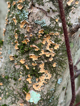

In [18]:
# preprocess & show image
image = Image.open(BytesIO(animal_image.content))

w, h = image.size
new_w = 80
new_h = int(h * (new_w / w))

image = image.convert("RGB")
image = image.resize((new_w, new_h))

display(image)

In [8]:
# convert image into Numpy array
image_arr = np.array(image)
print(image_arr.shape)

(333, 250, 3)


This shows that the image is a 3D tensor, & has a height of 178, width of 250, & 3 colour channels (RGB).

In [9]:
# check pixel range
print("data type: %s" % image_arr.dtype)
print("min: %.3f, max: %.3f" % (image_arr.min(), image_arr.max()))

data type: uint8
min: 0.000, max: 255.000


In [10]:
# normalisation on image
image_arr = image_arr.astype("float32")
image_arr /= 255.0
print("min: %.3f, max: %.3f" % (image_arr.min(), image_arr.max()))

min: 0.000, max: 1.000


In [15]:
# flatten 3D tensor into a 1D tensor
flatten_arr = image_arr.flatten()

print("3D tensor:\n", image_arr)
print("flattened array:\n", flatten_arr)

3D tensor:
 [[[0.6901961  0.7019608  0.6745098 ]
  [0.69411767 0.7019608  0.6784314 ]
  [0.6862745  0.69803923 0.6666667 ]
  ...
  [0.49803922 0.49019608 0.4745098 ]
  [0.41960785 0.40784314 0.39215687]
  [0.78431374 0.78431374 0.7647059 ]]

 [[0.69411767 0.70980394 0.6784314 ]
  [0.69803923 0.70980394 0.68235296]
  [0.69411767 0.7019608  0.6784314 ]
  ...
  [0.65882355 0.6392157  0.627451  ]
  [0.6117647  0.59607846 0.58431375]
  [0.8156863  0.8039216  0.78431374]]

 [[0.7058824  0.7176471  0.6901961 ]
  [0.7019608  0.7176471  0.6862745 ]
  [0.69803923 0.7176471  0.6901961 ]
  ...
  [0.7137255  0.7019608  0.68235296]
  [0.7137255  0.7058824  0.6784314 ]
  [0.7882353  0.7764706  0.7372549 ]]

 ...

 [[0.2627451  0.2901961  0.24705882]
  [0.32156864 0.34901962 0.31764707]
  [0.41960785 0.4392157  0.40392157]
  ...
  [0.31764707 0.2901961  0.21960784]
  [0.3137255  0.30980393 0.22352941]
  [0.30980393 0.30980393 0.21176471]]

 [[0.2627451  0.28235295 0.22352941]
  [0.29411766 0.31764707 

### Preprocess all data for ML task